# **Bubble Plots**


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()

--2026-02-05 07:27:53--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  58.1MB/s    in 2.6s    

2026-02-05 07:27:56 (58.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [3]:
# Map age ranges to numeric midpoints
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}
df['Age_numeric'] = df['Age'].map(age_map)

# Ensure numeric values
df['SOPartFreq'] = pd.to_numeric(df['SOPartFreq'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Drop missing values
df_clean = df.dropna(subset=['Age_numeric', 'SOPartFreq', 'JobSat'])

/tmp/ipykernel_4648/2459189453.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Job Satisfaction", bbox_to_anchor=(1.05, 1), loc='upper left')


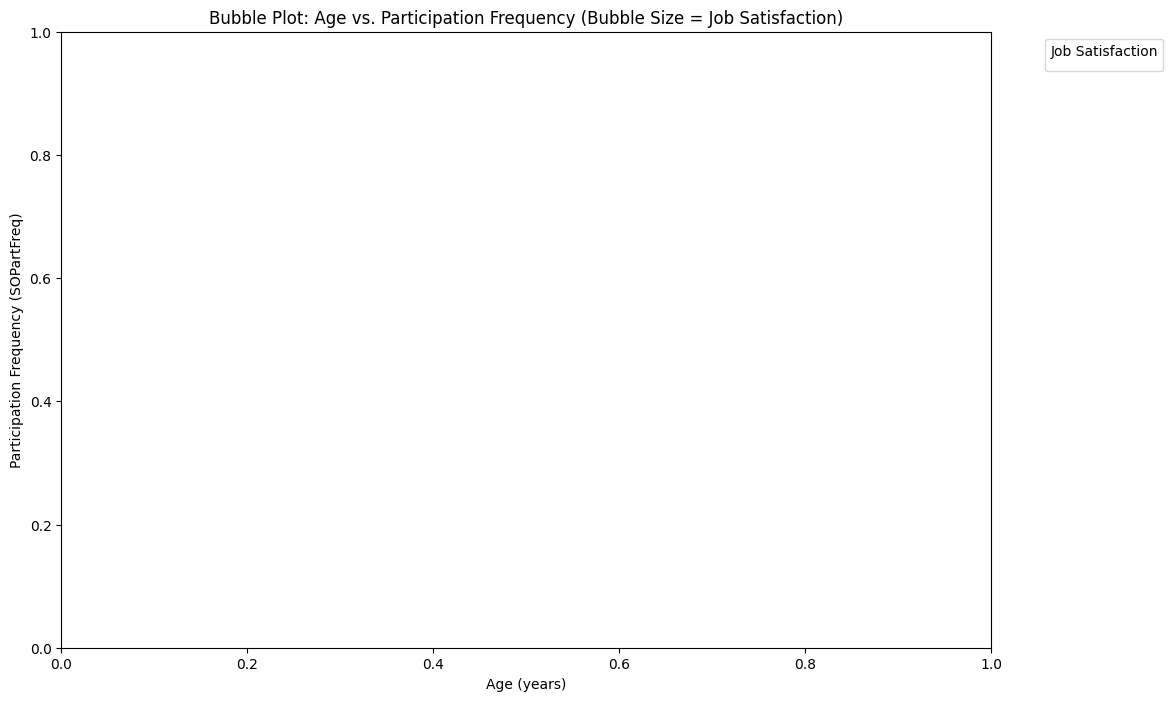

In [5]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x="Age_numeric",
    y="SOPartFreq",
    size="JobSat",             # bubble size = job satisfaction
    sizes=(50, 500),           # scale bubble sizes
    alpha=0.6,
    data=df_clean,
    color="royalblue"
)

plt.title("Bubble Plot: Age vs. Participation Frequency (Bubble Size = Job Satisfaction)")
plt.xlabel("Age (years)")
plt.ylabel("Participation Frequency (SOPartFreq)")
plt.legend(title="Job Satisfaction", bbox_to_anchor=(1.05, 1), loc='upper left')

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [6]:
# Ensure numeric values
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Drop missing values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSat', 'Age_numeric'])

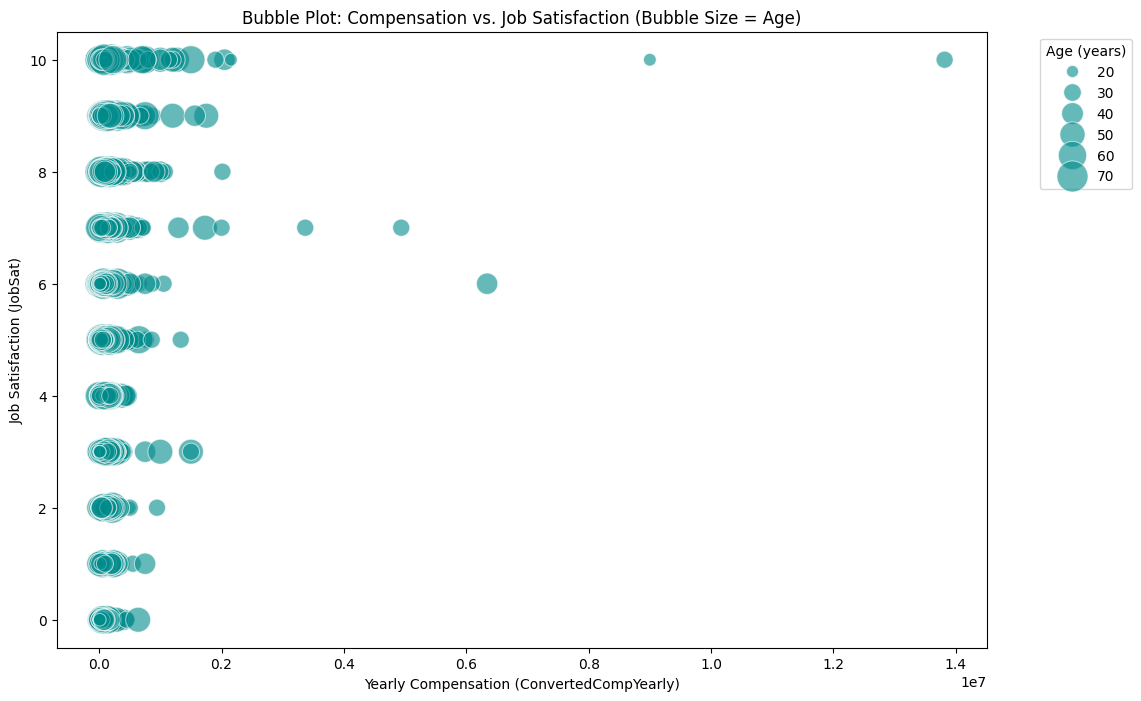

In [7]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x="ConvertedCompYearly",
    y="JobSat",
    size="Age_numeric",          # bubble size = age
    sizes=(50, 500),             # scale bubble sizes
    alpha=0.6,
    data=df_clean,
    color="darkcyan"
)

plt.title("Bubble Plot: Compensation vs. Job Satisfaction (Bubble Size = Age)")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Job Satisfaction (JobSat)")
plt.legend(title="Age (years)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [9]:
# Split multiple languages into separate rows
df_lang = df.assign(LanguageHaveWorkedWith=df['LanguageHaveWorkedWith'].str.split(';')).explode('LanguageHaveWorkedWith')
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.strip()

lang_summary = df_lang.groupby(['Age_numeric', 'LanguageHaveWorkedWith']).size().reset_index(name='Frequency')

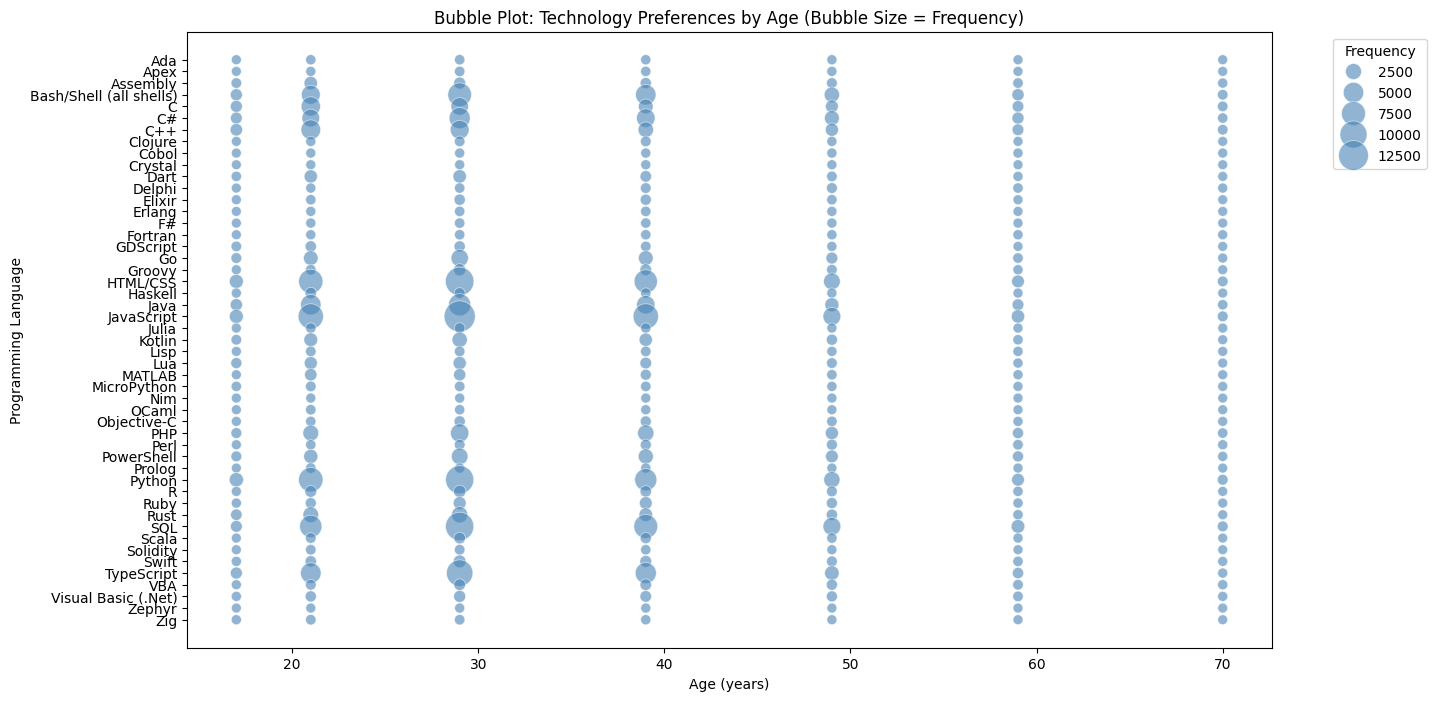

In [10]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    x="Age_numeric",
    y="LanguageHaveWorkedWith",
    size="Frequency",           # bubble size = frequency
    sizes=(50, 500),            # scale bubble sizes
    alpha=0.6,
    data=lang_summary,
    color="steelblue"
)

plt.title("Bubble Plot: Technology Preferences by Age (Bubble Size = Frequency)")
plt.xlabel("Age (years)")
plt.ylabel("Programming Language")
plt.legend(title="Frequency", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [12]:
df_db = df.assign(DatabaseWantToWorkWith=df['DatabaseWantToWorkWith'].str.split(';')).explode('DatabaseWantToWorkWith')
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.strip()

df_db['JobSat'] = pd.to_numeric(df_db['JobSat'], errors='coerce')
df_db = df_db.dropna(subset=['DatabaseWantToWorkWith', 'JobSat'])

In [13]:
db_summary = df_db.groupby('DatabaseWantToWorkWith').agg(
    AvgSatisfaction=('JobSat', 'mean'),
    RespondentCount=('JobSat', 'count')
).reset_index()

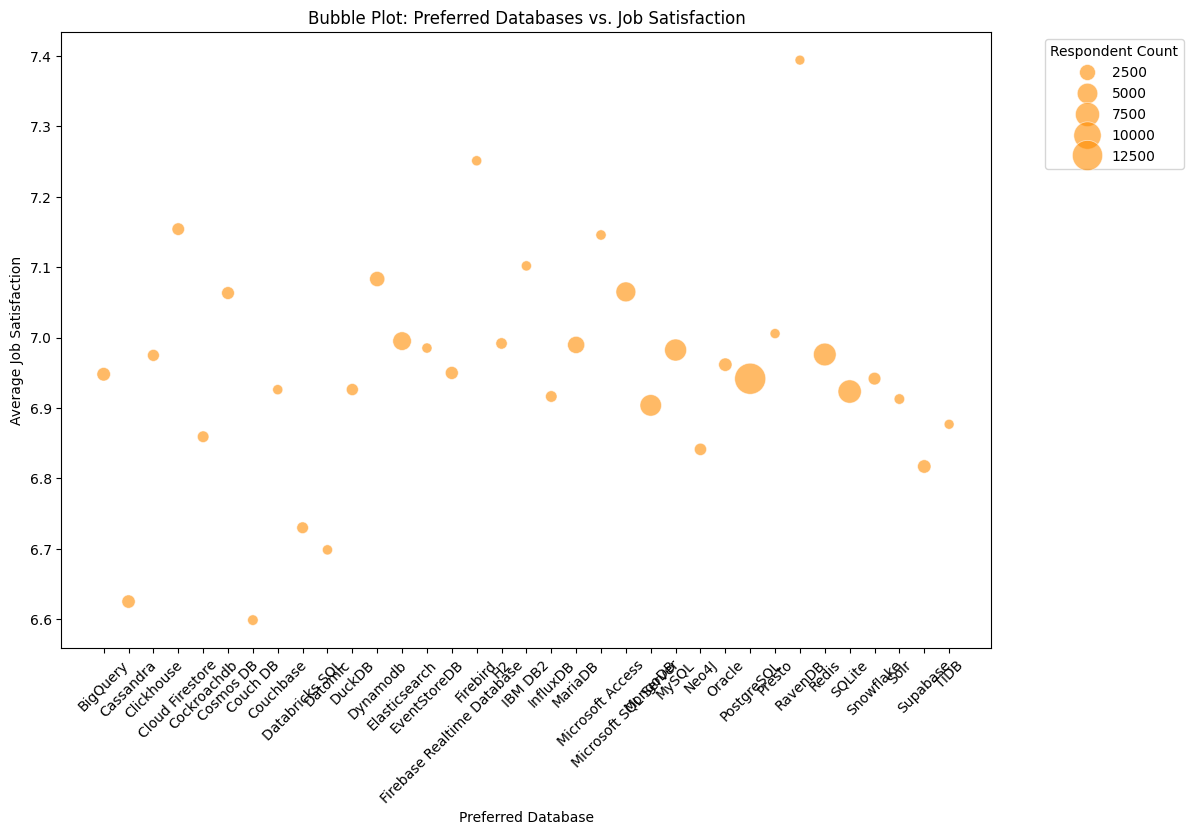

In [14]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x="DatabaseWantToWorkWith",
    y="AvgSatisfaction",
    size="RespondentCount",        # bubble size = number of respondents
    sizes=(50, 500),               # scale bubble sizes
    alpha=0.6,
    data=db_summary,
    color="darkorange"
)

plt.title("Bubble Plot: Preferred Databases vs. Job Satisfaction")
plt.xlabel("Preferred Database")
plt.ylabel("Average Job Satisfaction")
plt.xticks(rotation=45)
plt.legend(title="Respondent Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [15]:
# Split multiple roles into separate rows
df_roles = df.assign(DevType=df['DevType'].str.split(';')).explode('DevType')
df_roles['DevType'] = df_roles['DevType'].str.strip()

# Ensure numeric values
df_roles['ConvertedCompYearly'] = pd.to_numeric(df_roles['ConvertedCompYearly'], errors='coerce')
df_roles['JobSat'] = pd.to_numeric(df_roles['JobSat'], errors='coerce')

# Drop missing values
df_clean = df_roles.dropna(subset=['DevType', 'ConvertedCompYearly', 'JobSat'])

In [16]:
role_summary = df_clean.groupby('DevType').agg(
    AvgCompensation=('ConvertedCompYearly', 'mean'),
    AvgSatisfaction=('JobSat', 'mean'),
    RespondentCount=('JobSat', 'count')
).reset_index()

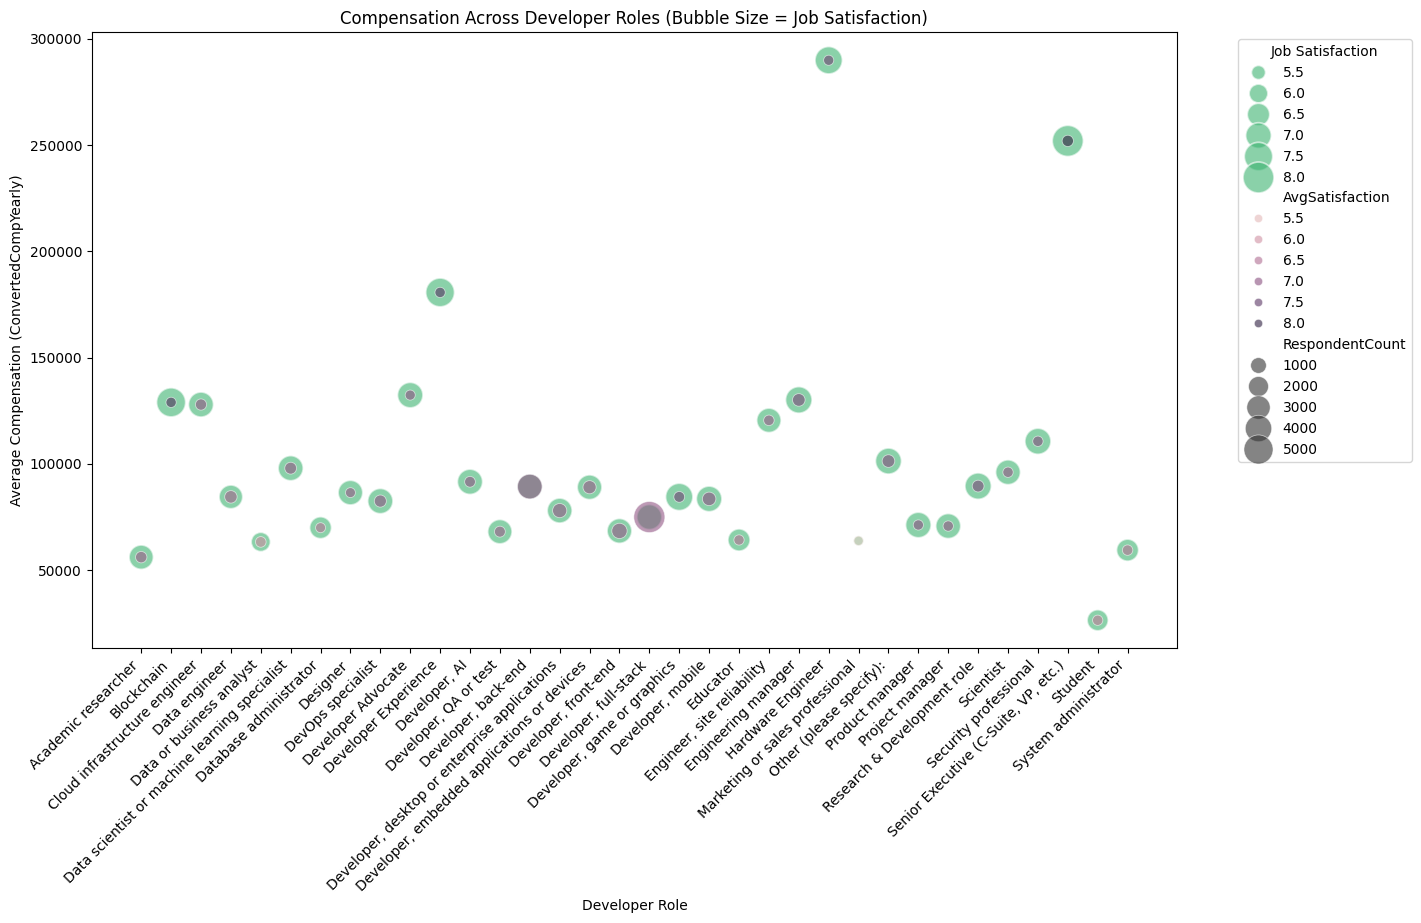

In [19]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    x="DevType",
    y="AvgCompensation",
    size="AvgSatisfaction",       # bubble size = job satisfaction
    sizes=(50, 500),              # scale bubble sizes
    alpha=0.6,
    data=role_summary,
    color="mediumseagreen"
)
sns.scatterplot(
    x="DevType",
    y="AvgCompensation",
    size="RespondentCount",
    hue="AvgSatisfaction",
    sizes=(50, 500),
    alpha=0.6,
    data=role_summary
)

plt.title("Compensation Across Developer Roles (Bubble Size = Job Satisfaction)")
plt.xlabel("Developer Role")
plt.ylabel("Average Compensation (ConvertedCompYearly)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Job Satisfaction", bbox_to_anchor=(1.05, 1), loc='upper left')

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [20]:
# Split multiple tools into separate rows
df_tools = df.assign(NEWCollabToolsHaveWorkedWith=df['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('NEWCollabToolsHaveWorkedWith')
df_tools['NEWCollabToolsHaveWorkedWith'] = df_tools['NEWCollabToolsHaveWorkedWith'].str.strip()

In [21]:
tool_summary = df_tools.groupby(['Age_numeric', 'NEWCollabToolsHaveWorkedWith']).size().reset_index(name='Frequency')

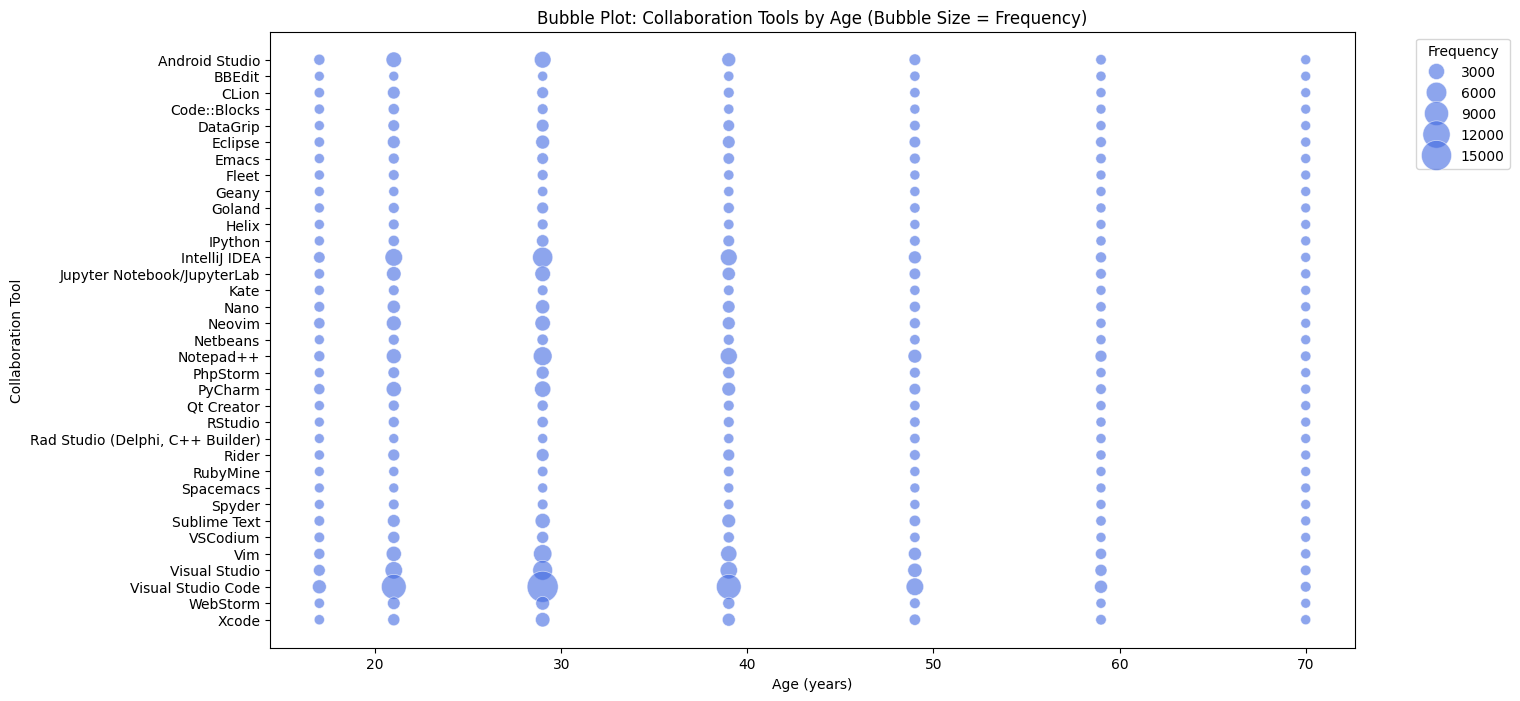

In [22]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    x="Age_numeric",
    y="NEWCollabToolsHaveWorkedWith",
    size="Frequency",           # bubble size = frequency
    sizes=(50, 500),            # scale bubble sizes
    alpha=0.6,
    data=tool_summary,
    color="royalblue"
)

plt.title("Bubble Plot: Collaboration Tools by Age (Bubble Size = Frequency)")
plt.xlabel("Age (years)")
plt.ylabel("Collaboration Tool")
plt.legend(title="Frequency", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [24]:
# Split multiple frameworks into separate rows
df_web = df.assign(WebframeWantToWorkWith=df['WebframeWantToWorkWith'].str.split(';')).explode('WebframeWantToWorkWith')
df_web['WebframeWantToWorkWith'] = df_web['WebframeWantToWorkWith'].str.strip()

df_web['JobSat'] = pd.to_numeric(df_web['JobSat'], errors='coerce')
df_web = df_web.dropna(subset=['WebframeWantToWorkWith', 'JobSat'])

In [25]:
framework_summary = df_web.groupby('WebframeWantToWorkWith').agg(
    AvgSatisfaction=('JobSat', 'mean'),
    RespondentCount=('JobSat', 'count')
).reset_index()

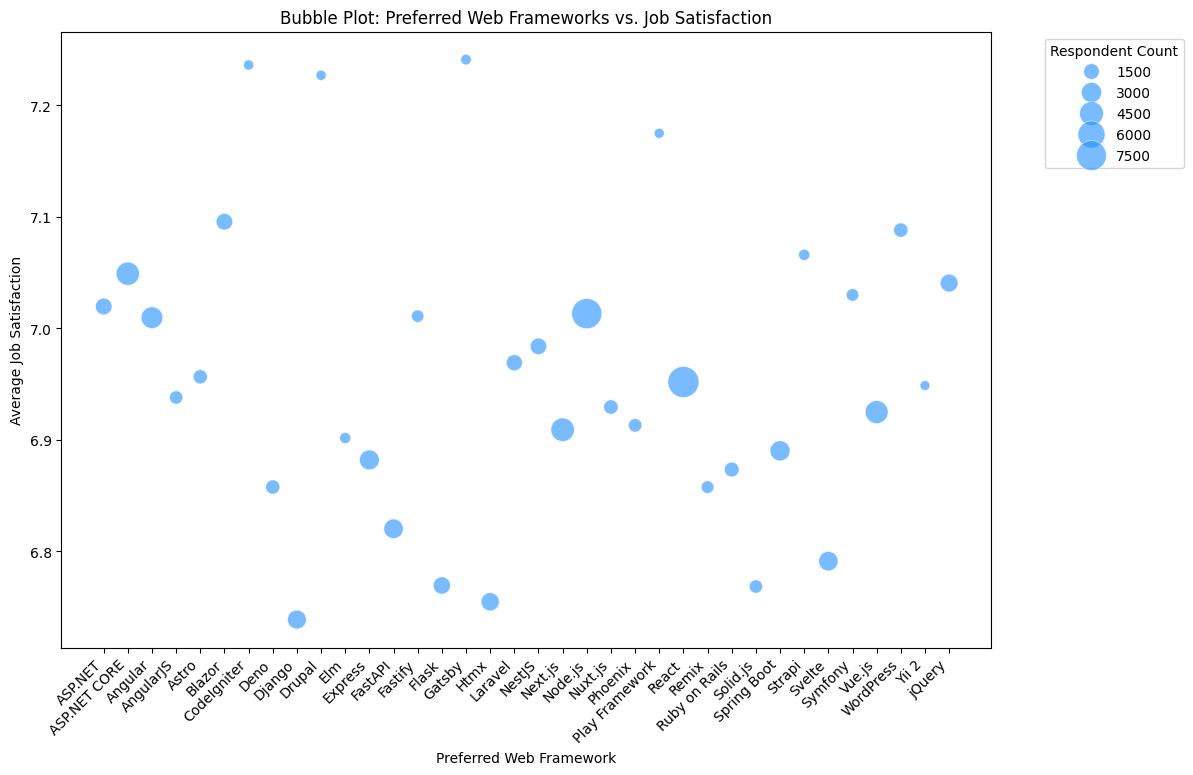

In [26]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x="WebframeWantToWorkWith",
    y="AvgSatisfaction",
    size="RespondentCount",        # bubble size = number of respondents
    sizes=(50, 500),               # scale bubble sizes
    alpha=0.6,
    data=framework_summary,
    color="dodgerblue"
)

plt.title("Bubble Plot: Preferred Web Frameworks vs. Job Satisfaction")
plt.xlabel("Preferred Web Framework")
plt.ylabel("Average Job Satisfaction")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Respondent Count", bbox_to_anchor=(1.05, 1), loc='upper left')

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [28]:
# Split multiple admired technologies into separate rows
df_admired = df.assign(LanguageAdmired=df['LanguageAdmired'].str.split(';')).explode('LanguageAdmired')
df_admired['LanguageAdmired'] = df_admired['LanguageAdmired'].str.strip()

df_admired = df_admired.dropna(subset=['LanguageAdmired', 'Country'])

In [29]:
admired_summary = df_admired.groupby(['Country', 'LanguageAdmired']).size().reset_index(name='Frequency')

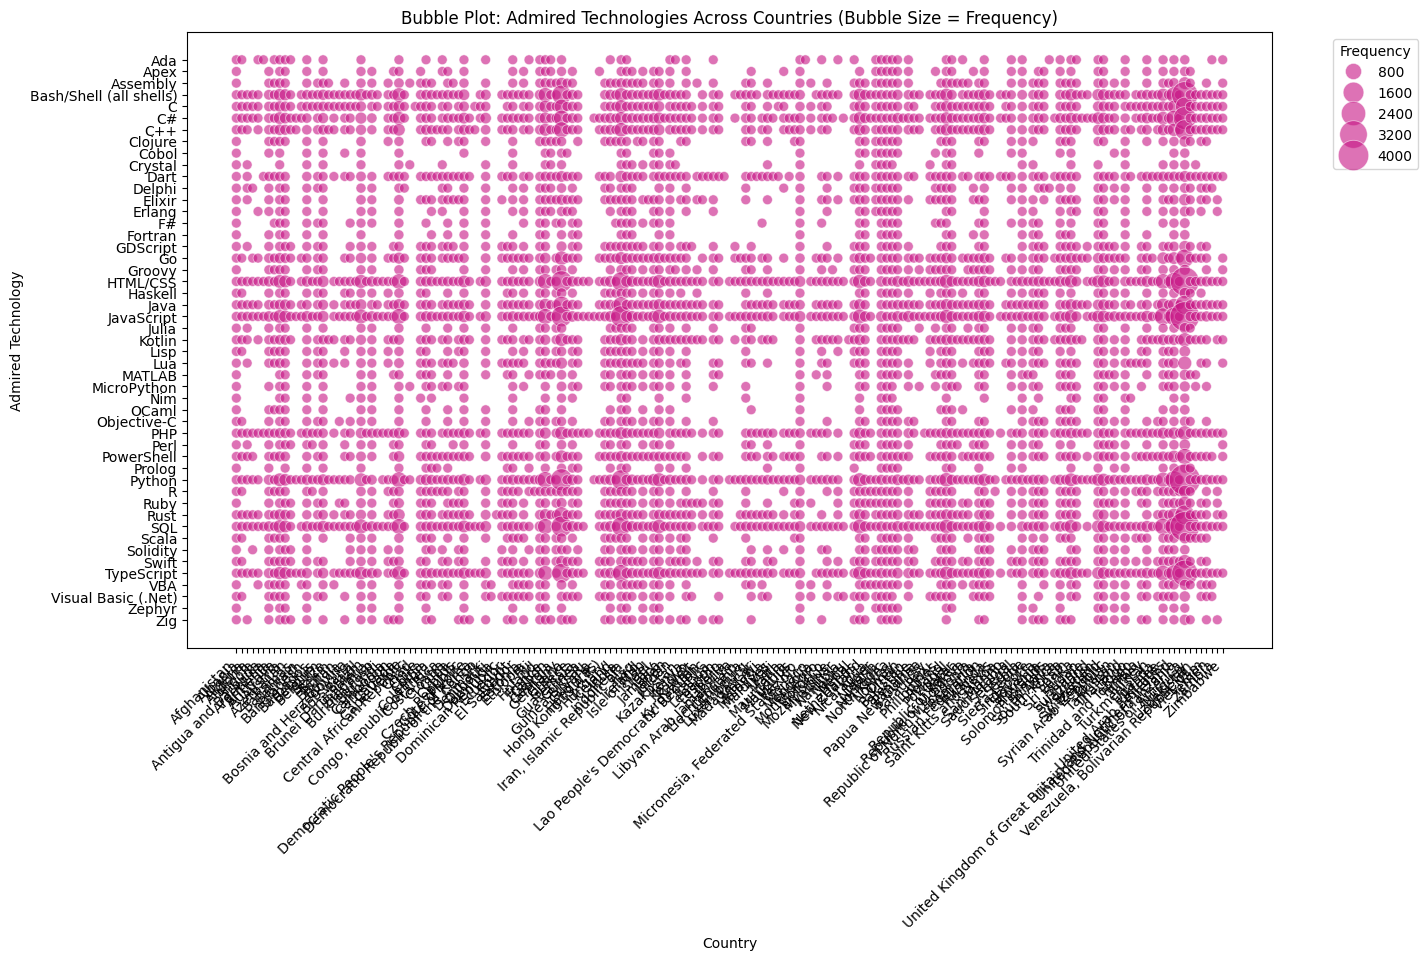

In [32]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    x="Country",
    y="LanguageAdmired",
    size="Frequency",           # bubble size = frequency
    sizes=(50, 500),            # scale bubble sizes
    alpha=0.6,
    data=admired_summary,
    color="mediumvioletred"
)

plt.title("Bubble Plot: Admired Technologies Across Countries (Bubble Size = Frequency)")
plt.xlabel("Country")
plt.ylabel("Admired Technology")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Frequency", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


Copyright © IBM Corporation. All rights reserved.
